### Previsão de Duração

In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', 300)  
pd.set_option('display.max_colwidth', None)  

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import (GradientBoostingRegressor, RandomForestRegressor, HistGradientBoostingRegressor)
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_excel("LW-DATASET-TRATADO.xlsx")
print(df.shape)

(122543, 28)


In [5]:
df.head()

,Número,Prioridade,Produto,Categoria,Subcategoria,Grupo designado,Item de configuração,Aberto,Resolvido,Encerrado,Duração,Código de fechamento,Descrição resumida,Solução,Aberto por,Incidente Pai,Status,Entrou para KPI?,KPI Violado?,tem_resolucao,tem_pai,tem_produto,tem_categoria,tem_subcategoria,tem_item_config,tem_CF,kpi_violado,kpi_nao_aplicavel
0,INC8654273,3 - Média,MONITORING_AUTO,INFRA_Monitoramento,INFRA_Monitoramento_Geral,Team14,IC00001,2025-12-31 23:45:18,2025-12-31 23:45:32,2025-12-31 23:45:32,14,AUTO_SEM_INTERVENCAO,Problem: Apache Busy Workers,SEM_SOLUCAO,Monitoramento,NaN,Sem Intervenção,NAO,NAO_APLICAVEL,0,0,0,0,0,1,0,0,1
1,INC8654270,4 - Baixa,MONITORING_AUTO,INFRA_Monitoramento,INFRA_Monitoramento_Geral,Team14,IC00002,2025-12-31 23:39:36,2025-12-31 23:43:05,2025-12-31 23:43:05,209,AUTO_SEM_INTERVENCAO,Problem: Check Application Monitoring,SEM_SOLUCAO,Monitoramento,NaN,Sem Intervenção,NAO,NAO_APLICAVEL,0,0,0,0,0,1,0,0,1
2,INC8654264,4 - Baixa,MONITORING_AUTO,INFRA_Monitoramento,INFRA_Monitoramento_Geral,Team14,SEM_IC,2025-12-31 23:23:10,2025-12-31 23:25:00,2025-12-31 23:25:00,110,AUTO_SEM_INTERVENCAO,"Problem: Alarm Application Monitoring database Message: HTTPSConnectionPool(host='centraldoclienteIC04172locawebIC04172comIC04172br', port=443): Read timed out. (read timeout=25)",SEM_SOLUCAO,Monitoramento,NaN,Sem Intervenção,NAO,NAO_APLICAVEL,0,0,0,0,0,0,0,0,1
3,INC8654263,4 - Baixa,MONITORING_AUTO,INFRA_Monitoramento,INFRA_Monitoramento_Geral,Team14,SEM_IC,2025-12-31 23:23:07,2025-12-31 23:24:57,2025-12-31 23:24:57,110,AUTO_SEM_INTERVENCAO,"Problem: Alarm Application Monitoring coupons Message: HTTPSConnectionPool(host='centraldoclienteIC04172locawebIC04172comIC04172br', port=443): Read timed out. (read timeout=25)",SEM_SOLUCAO,Monitoramento,NaN,Sem Intervenção,NAO,NAO_APLICAVEL,0,0,0,0,0,0,0,0,1
4,INC8654262,4 - Baixa,MONITORING_AUTO,INFRA_Monitoramento,INFRA_Monitoramento_Geral,Team14,IC00003,2025-12-31 23:23:05,2025-12-31 23:23:47,2025-12-31 23:23:47,42,AUTO_SEM_INTERVENCAO,Problem: Check Application Monitoring,SEM_SOLUCAO,Monitoramento,NaN,Sem Intervenção,NAO,NAO_APLICAVEL,0,0,0,0,0,1,0,0,1


### Transformando variável Target (log1p)

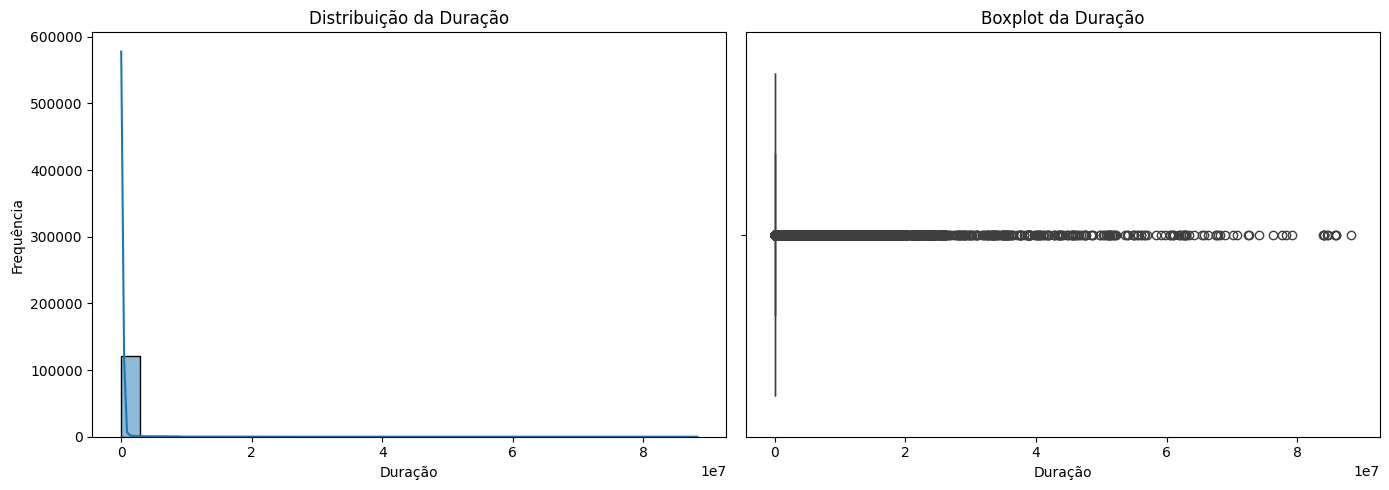

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Duração'].dropna(), bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribuição da Duração')
axes[0].set_xlabel('Duração')
axes[0].set_ylabel('Frequência')

sns.boxplot(x=df['Duração'], ax=axes[1])
axes[1].set_title('Boxplot da Duração')
axes[1].set_xlabel('Duração')

plt.tight_layout()
plt.show()

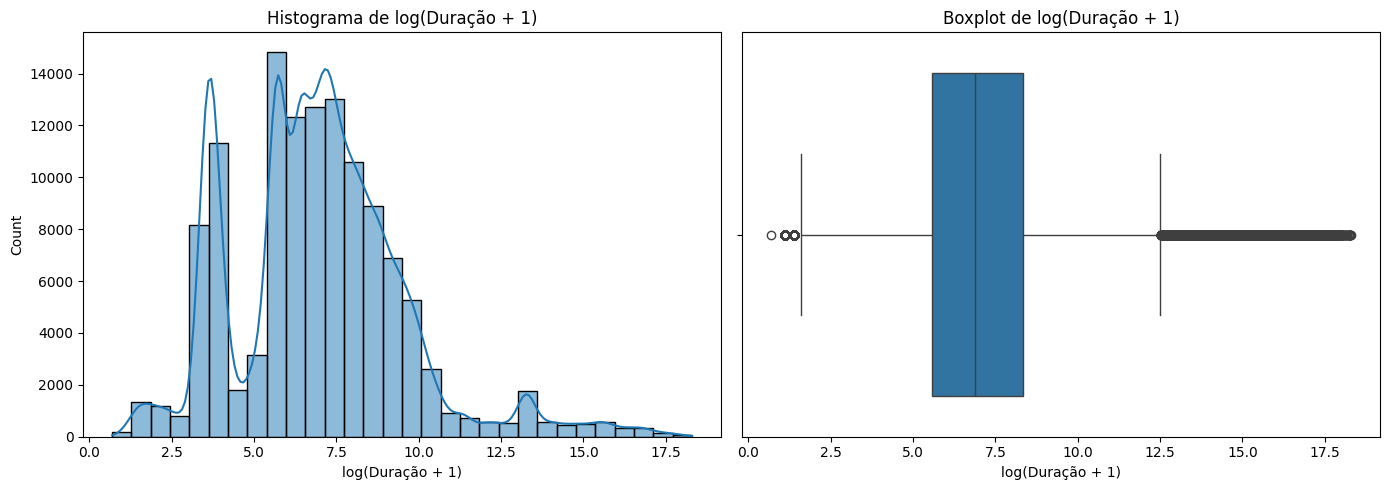

In [ ]:
df['Duracao_log'] = np.log1p(df['Duração'])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Duracao_log'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Histograma de log(Duração + 1)')
axes[0].set_xlabel('log(Duração + 1)')

sns.boxplot(x=df['Duracao_log'], ax=axes[1])
axes[1].set_title('Boxplot de log(Duração + 1)')
axes[1].set_xlabel('log(Duração + 1)')

plt.tight_layout()
plt.show()

### Feature Engineering

In [10]:
df['Aberto'] = pd.to_datetime(df['Aberto'])
df['hora_aberto'] = df['Aberto'].dt.hour

In [18]:
df['dia_semana'] = df['Aberto'].dt.dayofweek
df['fim_semana'] = df.dia_semana.isin([5, 6]).astype(int)
df['fora_comercial'] = ((df.hora_aberto < 8) | (df.hora_aberto >= 18)).astype(int)
df['monitoramento'] = (df["Aberto por"] == 'Monitoramento').astype(int)

In [ ]:
map_prioridade = {'1 - Crítica': 1, '2 - Alta': 2, '3 - Média': 3, '4 - Baixa': 4, '5 - Muito Baixa': 5}
df['prioridade_num'] = df['Prioridade'].map(map_prioridade)

In [ ]:
cat = ['Produto', 'Categoria', 'Grupo designado']
num = ['prioridade_num', 'hora_aberto', 'fim_semana', 'fora_comercial', 'monitoramento', 'tem_pai']

### Modelo

In [20]:
X = df[cat + num]
y = df['Duracao_log']

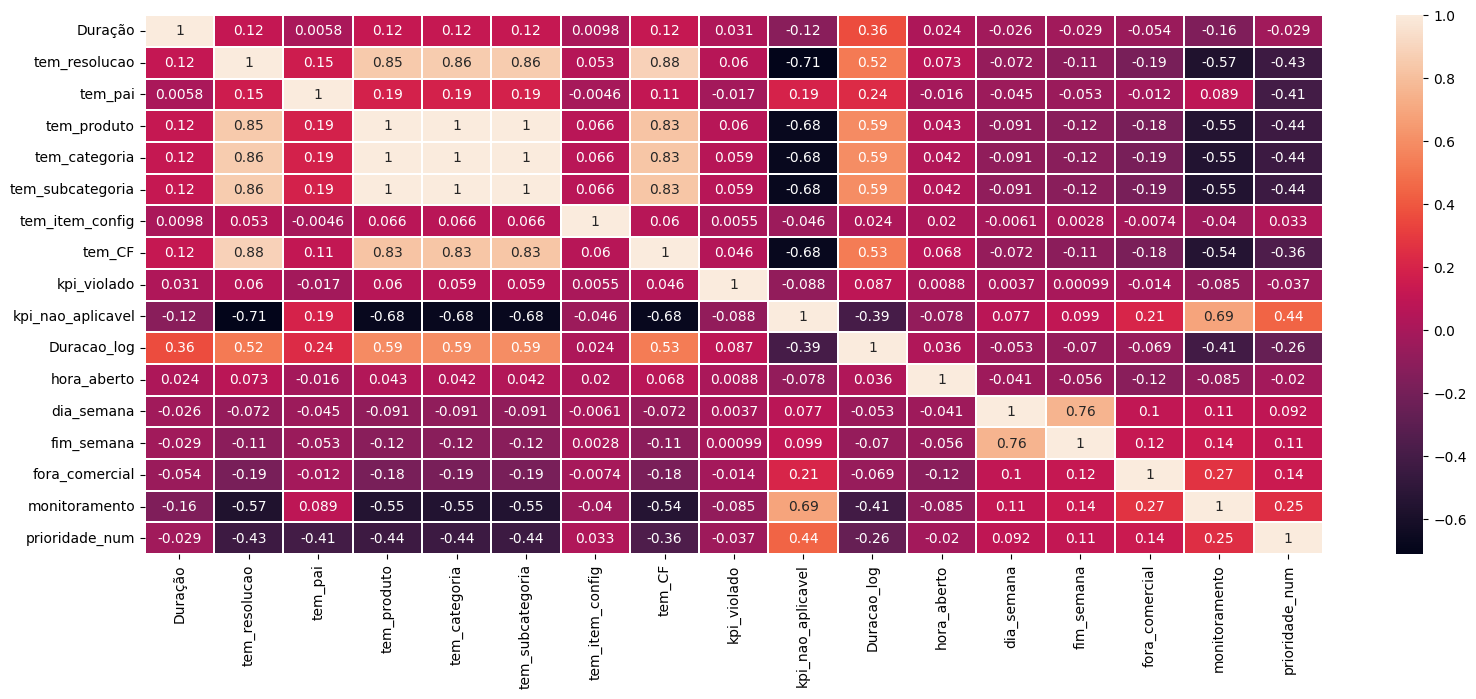

In [21]:
matriz_correlacao = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(19, 7))
sns.heatmap(matriz_correlacao, annot = True, linewidths = 0.2)
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = pd.get_dummies(X_train, columns=cat)
X_test = pd.get_dummies(X_test, columns=cat)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

## Benchmark de Modelos

In [ ]:
modelos = {
    'Baseline': DummyRegressor(strategy='mean'),
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1),

    'GradientBoosting': GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42),

    'HistGradientBoosting': HistGradientBoostingRegressor(
        max_iter=100,
        learning_rate=0.05,
        random_state=42)}

resultados = []
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    resultados.append({
        'Modelo': nome,
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'R²': r2_score(y_test, pred),
        'MAPE (%)': (np.mean(np.abs((y_test - pred) / y_test)) * 100)})

comparacao = (pd.DataFrame(resultados).sort_values('MAE').reset_index(drop=True))
comparacao

,Modelo,MAE,RMSE,R²,MAPE (%)
0,RandomForest,1.259078,1.717925,0.566252,24.137178
1,HistGradientBoosting,1.300955,1.731325,0.559459,24.727237
2,GradientBoosting,1.357821,1.800566,0.523518,25.552694
3,LinearRegression,1.479283,1.914266,0.461441,27.425211
4,Baseline,1.952771,2.608480,-0.000009,37.026900


In [ ]:
model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)

model.fit(X_train, y_train)
pred = model.predict(X_test)

print('MAE:', mean_absolute_error(y_test, pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, pred)))
print('R²:', r2_score(y_test, pred))

mape = np.mean(np.abs((y_test - pred) / y_test)) * 100
print(f'MAPE: {mape:.2f}%')

MAE: 1.2590783722727061
RMSE: 1.7179251493857142
R²: 0.5662522236370475
MAPE: 24.14%


In [41]:
real_h = np.expm1(y_test) / 3600
prev_h = np.expm1(pred) / 3600
erro_h = np.abs(prev_h - real_h)

print(f'\nErro mediano: {np.median(erro_h):.1f} horas')
print(f'Dentro de 2h: {(erro_h <= 2).mean()*100:.0f}% dos casos')
print(f'Dentro de 1h: {(erro_h <= 1).mean()*100:.0f}% dos casos')
print(f'Dentro de 30m: {(erro_h <= 0.5).mean()*100:.0f}% dos casos')
print(f'Dentro de 15m: {(erro_h <= 0.25).mean()*100:.0f}% dos casos')


Erro mediano: 0.1 horas
Dentro de 2h: 85% dos casos
Dentro de 1h: 79% dos casos
Dentro de 30m: 70% dos casos
Dentro de 15m: 59% dos casos


0.1 × 60 = 6 minutos ---> Erro mediano de 6 minutos

In [38]:
df_export = pd.DataFrame()
df_export['Numero_Incidente'] = df.loc[X_test.index, 'Número']
df_export['Duracao_Real'] = np.expm1(y_test)
df_export['Duracao_Prevista'] = np.expm1(pred)

df_export = df_export.sort_values(by='Duracao_Prevista', ascending=False)

filename = 'export_previsao_duracao.csv'
df_export.to_csv(filename, index=False)
print(f"Arquivo '{filename}' gerado com sucesso!")

Arquivo 'export_previsao_duracao.csv' gerado com sucesso!
